# Workflow Patterns

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4.1-mini")

## 1. Routing Pattern
입력 유형에 따라 다른 노드로 보내는 패턴을 의미한다.

다음 상황에 적합하게 사용 될 수 있다.
1. 요청 유형별로 프롬프트가 달라져야 할 때
2. 처리 방식이 명확히 나뉠 때
3. 모든 요청을 하나의 프롬프트로 처리하면 품질이 떨어질 때

In [3]:
from pydantic import BaseModel, Field
from typing import Annotated, Literal
from typing_extensions import TypedDict

class RouteDecision(BaseModel):
    route: Literal["translation", "summary", "qa"] = Field(
        description="사용자 요청을 처리할 경로"
    )
    reason: str = Field(
        description="해당 경로를 선택한 이유"
    )

route_llm = llm.with_structured_output(RouteDecision)

class RoutingState(TypedDict):
    user_input: str
    route: str
    reason: str
    answer: str

In [4]:
def classify_request(state: RoutingState):
    """사용자 요청을 번역, 요약, 일반 질문 중 하나로 분류한다."""

    decision = route_llm.invoke(
        [
            {
                "role" : "system",
                "content" : (
                    "사용자 요청을 다음 세 가지 중 하나로 분류하세요. \n"
                    "- translation: 번역 요청\n"
                    "- summary: 요약 요청\n"
                    "- qa: 일반 질문 또는 설명 요청\n"
                )
            },
            {
                "role" : "user",
                "content" : state["user_input"]
            }
        ]
    )

    return {
        "route" : decision.route,
        "reason" : decision.reason
    }

def route_by_decision(state: RoutingState):
    """분류 결과에 따라 다음 노드를 결정한다."""
    return state['route']

In [5]:
def translation_node(state: RoutingState):
    """번역 요청을 처리한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "사용자의 문장을 자연스러운 한국어로 번역하세요."
            },
            {
                "role" : "user",
                "content" : state['user_input']
            }
        ]
    )

    return {"answer" : response.content}

def summary_node(state: RoutingState):
    """요약 요청을 처리한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "사용자가 제공한 내용을 핵심만 3문장 이내로 요약하세요."
            },
            {
                "role" : "user",
                "content" : state['user_input']
            }
        ]
    )

    return {"answer" : response.content}

def qa_node(state: RoutingState):
    """일반 질문을 처리한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "사용자의 질문에 친절하고 정확하게 답변하세요."
            },
            {
                "role" : "user",
                "content" : state['user_input']
            }
        ]
    )

    return {"answer" : response.content}

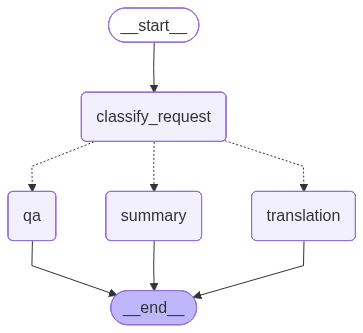

In [6]:
from langgraph.graph import StateGraph, START, END

routing_builder = StateGraph(RoutingState)

routing_builder.add_node("classify_request", classify_request)
routing_builder.add_node("translation", translation_node)
routing_builder.add_node("summary", summary_node)
routing_builder.add_node("qa", qa_node)

routing_builder.add_edge(START, "classify_request")

routing_builder.add_conditional_edges(
    "classify_request",
    route_by_decision,
    {"translation" : "translation",
     "summary" : "summary",
     "qa" : "qa"}
)

routing_builder.add_edge("translation", END)
routing_builder.add_edge("summary", END)
routing_builder.add_edge("qa", END)

routing_graph = routing_builder.compile()
routing_graph

In [7]:
# 번역 질문
routing_result = routing_graph.invoke({
    "user_input" : '다음 문장을 한국어로 번역해줘: I usually avoid spicy food.'
})

print('선택 된 경로 : ', routing_result['route'])
print('선택 된 이유 : ', routing_result['reason'])
print()
print(routing_result['answer'])

선택 된 경로 :  translation
선택 된 이유 :  사용자가 번역 요청임을 명확히 했기 때문에 번역 경로를 선택했습니다.

저는 보통 매운 음식을 피해요.


In [8]:
# 일반 질문
routing_result = routing_graph.invoke({
    "user_input" : '지구의 대기권은 어떤 층으로 구성 되어 있어?'
})

print('선택 된 경로 : ', routing_result['route'])
print('선택 된 이유 : ', routing_result['reason'])
print()
print(routing_result['answer'])

선택 된 경로 :  qa
선택 된 이유 :  사용자가 지구의 대기권에 대한 설명을 요청했기 때문에 일반 질문 또는 설명 요청(q&a)으로 분류합니다.

지구의 대기권은 여러 층으로 구성되어 있으며, 주로 다음과 같은 층들로 나뉩니다:

1. **대류권 (Troposphere)**  
   - 지표면에서 약 8~15km 높이까지 이어집니다.  
   - 우리가 생활하는 곳이며 기상 현상이 일어나는 층입니다.  
   - 기온이 높이 올라갈수록 감소합니다.

2. **성층권 (Stratosphere)**  
   - 대류권 바로 위, 약 15km에서 50km 높이까지 존재합니다.  
   - 오존층이 이 층에 위치해 자외선을 흡수합니다.  
   - 기온이 높이 올라갈수록 증가합니다.

3. **중간권 (Mesosphere)**  
   - 약 50km에서 85km 높이까지입니다.  
   - 기온이 다시 낮아지는 층이며, 유성(별똥별)이 이 층에서 타버립니다.

4. **열권 (Thermosphere)**  
   - 약 85km부터 500~1000km 이상까지 확장됩니다.  
   - 기온이 매우 높아질 수 있으며, 북극광과 남극광이 주로 이 층에서 발생합니다.

5. **외기권 (Exosphere)**  
   - 열권 위로 이어지는 층으로, 약 500~1000km 이상부터 수천 km까지 펼쳐집니다.  
   - 공기 밀도가 매우 낮아 우주와 거의 연결된 상태입니다.

이렇게 대기권은 여러 층으로 나누어지며, 각각 특성에 따라 기온 변화와 구성 성분이 다릅니다.


In [9]:
# 요약 질문
routing_result = routing_graph.invoke({
    "user_input" : """아래 문장을 요약해줘.
    
    지구의 대기권은 여러 층으로 구성되어 있으며, 주로 다음과 같은 층들로 나뉩니다:

1. **대류권 (Troposphere)**  
   - 지표면에서 약 8~15km 높이까지 이어집니다.  
   - 우리가 생활하는 곳이며 기상 현상이 일어나는 층입니다.  
   - 기온이 높이 올라갈수록 감소합니다.

2. **성층권 (Stratosphere)**  
   - 대류권 바로 위, 약 15km에서 50km 높이까지 존재합니다.  
   - 오존층이 이 층에 위치해 자외선을 흡수합니다.  
   - 기온이 높이 올라갈수록 증가합니다.

3. **중간권 (Mesosphere)**  
   - 약 50km에서 85km 높이까지입니다.  
   - 기온이 다시 낮아지는 층이며, 유성(별똥별)이 이 층에서 타버립니다.

4. **열권 (Thermosphere)**  
   - 약 85km부터 500~1000km 이상까지 확장됩니다.  
   - 기온이 매우 높아질 수 있으며, 북극광과 남극광이 주로 이 층에서 발생합니다.

5. **외기권 (Exosphere)**  
   - 열권 위로 이어지는 층으로, 약 500~1000km 이상부터 수천 km까지 펼쳐집니다.  
   - 공기 밀도가 매우 낮아 우주와 거의 연결된 상태입니다.

이렇게 대기권은 여러 층으로 나누어지며, 각각 특성에 따라 기온 변화와 구성 성분이 다릅니다.
    """
})

print('선택 된 경로 : ', routing_result['route'])
print('선택 된 이유 : ', routing_result['reason'])
print()
print(routing_result['answer'])

선택 된 경로 :  summary
선택 된 이유 :  사용자가 제공한 문장의 내용을 간결하게 정리해 달라고 명확하게 요청했기 때문에 요약 요청으로 분류함.

지구 대기권은 대류권, 성층권, 중간권, 열권, 외기권 등 여러 층으로 나뉘며 각 층은 고도에 따라 기온 변화와 특성이 다릅니다. 대류권은 우리가 생활하고 기상 현상이 일어나며, 성층권에는 오존층이 있어 자외선을 흡수합니다. 중간권에서는 유성이 타고, 열권에서는 북극광과 남극광이 발생하며, 외기권은 우주와 거의 이어진 매우 희박한 층입니다.


## 2. Parallelization Pattern
여러 노드를 동시에 실행하고 결과를 합치는 패턴이다.

이 패턴은 다음 상황에 적합하다.
1. 서로 독립적인 분석을 동시에 수행할 수 있을 때
2. 여러 관점의 결과를 합쳐야 할 때
3. 순차 실행보다 병렬 실행이 구조적으로 자연스러울 때

In [10]:
class ParallelState(TypedDict):
    topic: str
    market_analysis: str
    user_analysis: str
    risk_analysis: str
    final_report: str

In [11]:
def market_analysis_node(state: ParallelState):
    """시장 관점에서 주제를 분석한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "주어진 주제를 시장성과 수요 관점에서 간단히 분석하세요."
            },
            {
                "role" : "user",
                "content" : state['topic']
            }
        ]
    )

    return {"market_analysis" : response.content}

def user_analysis_node(state: ParallelState):
    """사용자 관점에서 주제를 분석한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "주어진 주제를 사용자 경험과 사용 가치 관점에서 간단히 분석하세요."
            },
            {
                "role" : "user",
                "content" : state['topic']
            }
        ]
    )

    return {"user_analysis" : response.content}

def risk_analysis_node(state: ParallelState):
    "위험 요소 관점에서 주제를 분석한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "주어진 주제를 위험 요소와 주의할 점을 간단히 분석하세요."
            },
            {
                "role" : "user",
                "content" : state['topic']
            }
        ]
    )

    return {"risk_analysis" : response.content}


In [12]:
def synthesize_parallel_node(state: ParallelState):
    """여러 관점의 분석 결과를 종합한다."""

    response = llm.invoke(
        [
            {
                "role" : "system",
                "content" : "여러 관점의 분석 결과를 종합해 짧은 의사결정 메모를 작성하세요."
            },
            {
                "role" : "user",
                "content" : (
                    f"주제 : {state['topic']}\n\n"
                    f"[시장 관점]\n{state['market_analysis']}\n\n"
                    f"[사용자 관점]\n{state['user_analysis']}\n\n"
                    f"[위험 요소 관점]\n{state['risk_analysis']}\n\n"
                )
            }
        ]
    )

    return {"final_report" : response.content}


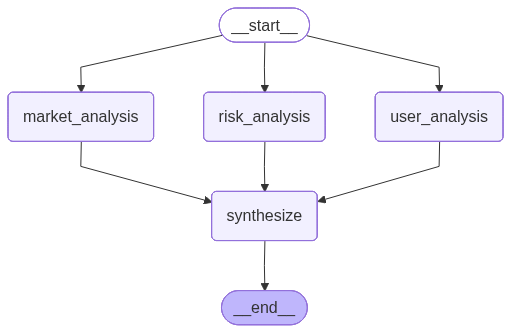

In [13]:
parallel_builder = StateGraph(ParallelState)

parallel_builder.add_node("market_analysis", market_analysis_node)
parallel_builder.add_node("user_analysis", user_analysis_node)
parallel_builder.add_node("risk_analysis", risk_analysis_node)
parallel_builder.add_node("synthesize", synthesize_parallel_node)

# START에서 여러 노드로 동시에 연결하면 병렬 실행 구조가 된다.
parallel_builder.add_edge(START, "market_analysis")
parallel_builder.add_edge(START, "user_analysis")
parallel_builder.add_edge(START, "risk_analysis")

# 세 분석 노드가 끝난 뒤 synthesize 노드에서 결과를 합친다.
parallel_builder.add_edge("market_analysis", "synthesize")
parallel_builder.add_edge("user_analysis", "synthesize")
parallel_builder.add_edge("risk_analysis", "synthesize")

parallel_builder.add_edge("synthesize", END)

parallel_graph = parallel_builder.compile()
parallel_graph

In [14]:
parallel_result = parallel_graph.invoke({
    'topic' : '개인 맞춤형 여행 추천 서비스'
})

print("[시장 관점]")
print(parallel_result['market_analysis'])
print("=" * 100)

print("[사용자 관점]")
print(parallel_result['user_analysis'])
print("=" * 100)

print("[위험 관점]")
print(parallel_result['risk_analysis'])
print("=" * 100)

print("[최종 레포트]")
print(parallel_result['final_report'])
print("=" * 100)

[시장 관점]
개인 맞춤형 여행 추천 서비스는 최근 여행 트렌드와 디지털화된 소비 패턴에 힘입어 시장성과 수요가 매우 긍정적입니다. 

1. 시장성:
- 맞춤형 서비스에 대한 소비자 선호 증가로, 개인의 취향과 예산에 최적화된 여행상품 제공 가능.
- 빅데이터와 인공지능 기술 발전으로 정교한 추천 시스템 구현이 용이.
- 글로벌 여행 산업 회복세와 함께 다양한 세대(특히 MZ세대)에서 개인화 경험에 대한 수요 증대.

2. 수요:
- 여행객들은 시간과 비용을 절감하면서도 자신만의 독특한 여행경험을 원함.
- 소셜미디어와 리뷰 기반의 정보 과부하로 인해 신뢰할 수 있는 맞춤형 추천에 대한 니즈 증가.
- 코로나19 이후 여행 패턴 변화로 안전하고 개인화된 여행 계획 수립에 대한 관심 확대.

종합적으로, 개인 맞춤형 여행 추천 서비스는 성장 가능성이 크며, 기술 활용과 사용자 경험 개선을 통해 경쟁력을 높일 수 있는 유망한 시장으로 평가됩니다.
[사용자 관점]
개인 맞춤형 여행 추천 서비스는 사용자 경험과 사용 가치 측면에서 다음과 같이 분석할 수 있습니다.

1. 사용자 경험 (UX)
- 맞춤화된 추천: 사용자의 취향, 예산, 이전 여행 기록 등을 반영해 개인화된 여행지를 제안함으로써 만족도를 높임.
- 편리성: 여행 계획 수립 과정에서 시간과 노력을 절약할 수 있어 사용자가 편리하게 여행 준비를 할 수 있음.
- 인터페이스: 직관적이고 사용하기 쉬운 UI로 사용자 접근성을 향상시켜 전반적인 경험을 개선함.
- 실시간 피드백: 사용자 리뷰와 평점, 최신 정보 제공을 통해 신뢰성을 강화함.

2. 사용 가치
- 효율적 계획: 복잡한 여행 일정 구성을 돕고 맞춤 추천으로 불필요한 선택 부담을 줄여 여행 준비 효율성을 증대함.
- 개인 맞춤 혜택: 사용자의 선호도에 부합하는 특별한 여행지나 활동을 발견할 수 있어 차별화된 만족감을 제공함.
- 비용 절감: 최적화된 추천을 통해 가성비 좋은 옵션을 제시, 예산 내에서 최고의 여행 경험을 할 수 있도록 지원함.
- 지속

## 3. Evaluator-Optimizer Pattern
생성 결과를 평가하고 부족하면 다시 개선하는 패턴이다.
답변 품질을 일정 수준 이상으로 끌어올리고 싶을 때 유용하다.

In [15]:
class Evaluation(BaseModel):
    grade: Literal["pass", "fail"] = Field(
        description="초안이 요구사항을 만족하면 pass, 부족하면 fail"
    )
    feedback: str = Field(
        description="개선이 필요한 경우 구체적인 피드백"
    )

evaluator_llm = llm.with_structured_output(Evaluation)

class EvalState(TypedDict):
    task: str
    draft: str
    feedback: str
    grade: str
    iteration: int

In [16]:
def generate_draft_node(state: EvalState):
    """초안을 생성하거나, 피드백을 반영해 다시 작성한다."""

    feedback = state.get("feedback", "")
    iteration = state.get("iteration", 0)

    if feedback:
        # 이전 평가에서 fail을 받은 경우에는 피드백과 이전 초안을 함께 전달한다.
        # 이렇게 해야 단순 재생성이 아니라 개선 작업이 된다.
        prompt = (
            f"다음 작업에 대한 초안을 피드백을 반영해 개선하세요.\n\n"
            f"작업: {state['task']}\n\n"
            f"이전 초안:\n{state.get('draft', '')}\n\n"
            f"피드백:\n{feedback}"
        )
    else:
        # 처음 실행될 때는 피드백이 없으므로 초안을 새로 작성한다.
        prompt = f"다음 작업에 대한 초안을 작성하세요.\n\n작업: {state['task']}"

    response = llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    "당신은 사용자의 작업 요구사항에 맞는 초안을 작성하는 작성자입니다. "
                    "요구사항을 충실히 반영하되, 처음에는 핵심 내용을 중심으로 간결하게 작성하세요. "
                    "이전 피드백이 제공되면 피드백을 반영해 더 완성도 높은 초안으로 개선하세요."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ]
    )

    return {
        "draft": response.content,
        "iteration": iteration + 1,
    }


def evaluate_draft_node(state: EvalState):
    """초안이 작업 요구사항을 만족하는지 평가한다."""

    # 수업에서는 Evaluator-Optimizer의 반복 구조를 반드시 확인하기 위해
    # 첫 번째 초안은 의도적으로 fail 처리한다.
    # 실제 서비스 코드에서는 이런 강제 fail 로직을 넣지 않는다.
    if state["iteration"] == 1:
        return {
            "grade": "fail",
            "feedback": (
                "첫 번째 초안은 반복 구조 확인을 위해 개선 대상으로 처리합니다. "
                "작업 요구사항을 더 명확히 반영하고, 내용의 구체성, 전달력, 완성도를 보강하세요."
            ),
        }

    # 두 번째 평가부터는 LLM이 실제로 pass/fail을 판단한다.
    evaluation = evaluator_llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    "당신은 초안을 검토하는 평가자입니다.\n"
                    "주어진 작업 요구사항과 초안을 비교하여 초안이 요구사항을 충분히 만족하는지 평가하세요.\n\n"
                    "다음 기준을 바탕으로 평가합니다.\n"
                    "1. 작업에서 요구한 목적과 대상이 초안에 반영되어 있는가?\n"
                    "2. 핵심 내용이 빠지지 않고 포함되어 있는가?\n"
                    "3. 표현이 지나치게 추상적이지 않고 구체적인가?\n"
                    "4. 문장의 흐름이 자연스럽고 실제로 사용할 수 있는 수준인가?\n\n"
                    "모든 기준을 충분히 만족하면 pass를 주세요.\n"
                    "하나라도 부족하면 fail을 주고, 무엇을 어떻게 보완해야 하는지 구체적으로 피드백하세요."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"작업 요구사항:\n{state['task']}\n\n"
                    f"초안:\n{state['draft']}"
                ),
            },
        ]
    )

    return {
        "grade": evaluation.grade,
        "feedback": evaluation.feedback,
    }


def should_continue(state: EvalState):
    """평가 결과에 따라 종료할지 다시 생성할지 결정한다."""

    if state["grade"] == "pass":
        return "end"

    # 수업용 예제에서는 무한 반복을 막기 위해 최대 3회까지만 생성한다.
    if state["iteration"] >= 3:
        return "end"

    return "revise"

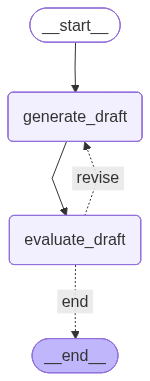

In [17]:
eval_builder = StateGraph(EvalState)

eval_builder.add_node("generate_draft", generate_draft_node)
eval_builder.add_node("evaluate_draft", evaluate_draft_node)

eval_builder.add_edge(START, "generate_draft")
eval_builder.add_edge("generate_draft", "evaluate_draft")

eval_builder.add_conditional_edges(
    "evaluate_draft",
    should_continue,
    {
        "revise" : "generate_draft",
        "end" : END
    }
)

eval_graph = eval_builder.compile()
eval_graph

In [19]:
eval_input = {
    'task' : '처음 방문하는 사용자를 위한 개인 맞춤형 여행 추천 서비스 소개 문구를 작성하세요.',
    'iteration' : 0,
    'feedback' : '',
    'draft' : '',
    'grade' : ''
}

for chunk in eval_graph.stream(
    eval_input,
    stream_mode='updates',
    version='v2'
):
    update = chunk['data']

    for node_name, node_update in update.items():
        print(f"[실행 된 노드] : {node_name}")

        if "iteration" in node_update:
            print("반복 횟수 :", node_update['iteration'])
        
        if "grade" in node_update:
            print("평가 :", node_update['grade'])

        if "feedback" in node_update:
            print("피드백 :", node_update['feedback'])

        if "draft" in node_update:
            print("초안", node_update['draft'])

        print("=" * 100)

[실행 된 노드] : generate_draft
반복 횟수 : 1
초안 안녕하세요! 당신만을 위한 맞춤형 여행 추천 서비스를 만나보세요. 여행 스타일, 취향, 예산을 반영해 완벽한 여행지를 제안해드립니다. 지금 간단한 질문에 답하고, 특별한 여행을 시작하세요!
[실행 된 노드] : evaluate_draft
평가 : fail
피드백 : 첫 번째 초안은 반복 구조 확인을 위해 개선 대상으로 처리합니다. 작업 요구사항을 더 명확히 반영하고, 내용의 구체성, 전달력, 완성도를 보강하세요.
[실행 된 노드] : generate_draft
반복 횟수 : 2
초안 안녕하세요! 여러분의 여행 스타일, 취향, 예산을 꼼꼼히 고려해 오직 당신만을 위한 맞춤 여행지를 추천해드립니다. 간단한 질문 몇 가지에 답하기만 하면, 특별하고 기억에 남을 여행을 손쉽게 계획할 수 있습니다. 지금 바로 시작해보세요!
[실행 된 노드] : evaluate_draft
평가 : pass
피드백 : 초안은 처음 방문하는 사용자에게 개인 맞춤형 여행 추천 서비스의 목적과 방식을 명확하게 전달하고 있습니다. 여행 스타일, 취향, 예산을 고려한다는 구체적인 내용이 포함되어 있어 추상적이지 않고 이해하기 쉽습니다. 문장 흐름도 자연스러워 실제 서비스에 바로 사용할 수 있는 수준입니다.


## 4. Orchestrator-Worker Pattern
하나의 작업을 여러 하위 작업으로 나눈 뒤, worker 노드들이 각각 처리하고 결과를 다시 합치는 패턴이다.
Orchestrator 가 입력을 보고 필요한 작업 목록을 동적으로 만든다.
보고서 작성, 문서 분석, 코드 리뷰처럼 작업을 여러 부분으로 나눌 수 있을 때 유용하다.

In [20]:
import operator

class SectionPlan(BaseModel):
    sections: list[str] = Field(
        description="작성해야 할 보고서 섹션 제목 목록"
    )

planner_llm = llm.with_structured_output(SectionPlan)

class ReportState(TypedDict):
    topic: str
    sections: list[str]
    completed_sections: Annotated[list[str], operator.add]
    final_report: str

class SectionState(TypedDict):
    topic: str
    section: str

In [21]:
from langgraph.types import Send

def orchestrator_node(state: ReportState):
    """보고서 주제를 보고 필요한 섹션 목록을 계획한다."""

    plan = planner_llm.invoke(
        [
            {
                "role" : "system",
                "content" : (
                        "주어진 주제에 대한 짧은 보고서를 작성하려고 합니다."
                        "필요한 섹션 제목을 여러 개로 나누세요."
                )
            },
            {
                "role" : "user",
                "content" : state['topic']
            }
        ]
    )

    return {
        "sections" : plan.sections,
        "completed_sections" : []
    }

def assign_workers(state: ReportState):
    """섹션 목록을 바탕으로 worker 실행을 동적으로 생성한다."""

    return [
        Send(
            "write_section",
            {
                'topic' : state['topic'],
                'section' : section
            }
        )
        for section in state['sections']
    ]

def write_section_node(state: SectionState):
    """하나의 섹션을 작성하는 worker 노드이다."""

    response = llm.invoke(
        [
            {
                'role' : 'system',
                'content' : '주어진 섹션에 대해 3~5문장 분량의 보고서 내용을 작성하세요.'
            },
            {
                'role' : 'user',
                'content' : (
                    f'보고서 주제 : {state['topic']}\n'
                    f'섹션 제목 : {state['section']}'
                )
            }
        ]
    )

    section_text = f'## {state['section']}\n{response.content}'

    return {
        "completed_sections" : [section_text]
    }

def synthesize_report_node(state: ReportState):
    """worker 들이 작성한 섹션을 하나의 보고서로 정리한다."""

    joined_sections = '\n\n'.join(state['completed_sections'])

    response = llm.invoke([
        {
            'role' : 'system',
            'content' : (
                '아래 섹션들을 자연스럽게 연결하여 최종 보고서로 정리하세요.'
                '섹션의 핵심은 유지하되, 전체 흐름이 어색하지 않게 다듬으세요.'
            )
        },
        {
            'role' : 'user',
            'content' : joined_sections
        }
    ])

    return {
        'final_report' : response.content
    }

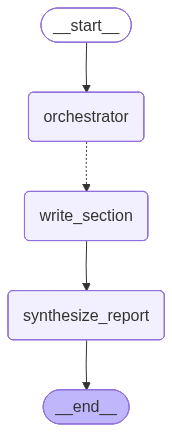

In [22]:
report_builder = StateGraph(ReportState)

report_builder.add_node('orchestrator', orchestrator_node)
report_builder.add_node('write_section', write_section_node)
report_builder.add_node('synthesize_report', synthesize_report_node)

report_builder.add_edge(START, "orchestrator")

report_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["write_section"]
)

report_builder.add_edge("write_section", "synthesize_report")
report_builder.add_edge("synthesize_report", END)

report_graph = report_builder.compile()
report_graph

In [23]:
report_input = {
    'topic' : 'AI 기반 개인 맞춤형 학습 도우미',
    'completed_sections' : []
}

for chunk in report_graph.stream(
    report_input,
    stream_mode='updates',
    version='v2'
):
    update = chunk['data']

    for node_name, node_update in update.items():
        print(f"[실행 된 노드] : {node_name}")

        if "sections" in node_update:
            print("[섹션 목록]")
            for section in node_update['sections']:
                print("-", section)
        
        if "completed_sections" in node_update:
            print("[작성 완료한 섹션]")
            for section in node_update['completed_sections']:
                print("-", section)

        if "final_report" in node_update:
            print("[최종 보고서]\n", node_update['final_report'])

        print("=" * 100)

[실행 된 노드] : orchestrator
[섹션 목록]
- 서론: AI 기반 개인 맞춤형 학습 도우미의 개요
- AI 기술의 역할과 적용 사례
- 개인 맞춤형 학습 도우미의 기능과 장점
- 개발 및 구현 방법
- 사례 연구: 실제 AI 학습 도우미 활용 예
- 도전 과제 및 미래 전망
- 결론: 개인 맞춤형 학습 도우미의 중요성 및 전망
[작성 완료한 섹션]
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## 개인 맞춤형 학습 도우미의 기능과 장점
AI 기반 개인 맞춤형 학습 도우미는 학습자의 수준, 관심사, 학습 스타일에 맞춰 최적화된 학습 계획을 제공합니다. 이를 통해 학습 효율성을 극대화하며, 실시간 피드백과 맞춤형 문제 출제로 학습자의 이해도를 지속적으로 향상시킬 수 있습니다. 또한, 시간과 장소에 구애받지 않고 언제든지 학습 지원을 받을 수 있어 자기주도 학습을 강화하는 데 큰 도움이 됩니다. 이러한 기능들은 학습 동기 부여와 성취감 증진에도 긍정적인 영향을 미칩니다.
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## 사례 연구: 실제 AI 학습 도우미 활용 예
사례 연구에서는 AI 기반 개인 맞춤형 학습 도우미가 실제 교육 현장에서 어떻게 활용되고 있는지 살펴본다. 예를 들어, 한 중학교에서는 AI 도우미를 통해 학생들의 학습 수준과 성향을 분석하여 개별 맞춤형 문제와 피드백을 제공함으로써 학습 효율을 크게 향상시켰다. 또한, AI 도우미는 실시간 질문 응답 기능을 통해 학생들이 어려움을 겪는 부분을 즉각적으로 지원하며, 교사의 부담을 경감시키는 역할도 수행하고 있다. 이러한 사례들은 AI 학습 도우미가 개인별 학습 경로 최적화와 교육 품질 제고에 실질적인 도움을 주고 있음을 보여준다.
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## AI 기술의 역할과 적용 사례
AI 기술은 개인 맞춤형 학습 도우미에서 핵심적인 역할을 수행하며, 학습자의 수준과 선호도를 분석하여 최